# Equation System Experiments

In [8]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler

# Plotting defaults for consistency and accessibility
plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.prop_cycle'] = cycler('color', plt.cm.get_cmap('Set2').colors)

from src.systems.newton_system import newton_system
from src.systems.broyden import broyden


/var/folders/rc/c14qrm5n3_g6ps2wp3vqjbm40000gn/T/ipykernel_6942/3240281986.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.rcParams['axes.prop_cycle'] = cycler('color', plt.cm.get_cmap('Set2').colors)


In [10]:
def extract_history_residuals(result):
    residuals = []

    for step in result["history"]:
        if "residual" in step:
            residuals.append(abs(float(step["residual"])))
        elif "fx" in step:
            residuals.append(abs(float(step["fx"])))
        elif "f_curr" in step:
            residuals.append(abs(float(step["f_curr"])))
        elif "fb" in step:
            residuals.append(abs(float(step["fb"])))
        elif "norm_f" in step:
            residuals.append(abs(float(step["norm_f"])))

    return residuals


def residuals_for_plot(result, atol=1e-12, rtol=1e-12, eps=1e-16):
    residuals = extract_history_residuals(result)

    final_residual = abs(float(result["final_residual"]))

    if not residuals or not np.isclose(residuals[-1], final_residual, atol=atol, rtol=rtol):
        residuals.append(final_residual)

    return [max(r, eps) for r in residuals]


def residual_consistency_report(results_dict):
    rows = []

    for name, result in results_dict.items():
        history_residuals = extract_history_residuals(result)
        plot_residuals = residuals_for_plot(result)

        history_last = history_residuals[-1] if history_residuals else None
        plot_last = plot_residuals[-1] if plot_residuals else None
        final_residual = abs(float(result["final_residual"]))

        rows.append({
            "Method": name,
            "Iterations": result["iterations"],
            "History Last Residual": history_last,
            "Final Residual": final_residual,
            "Plot Last Residual": plot_last,
            "Matches": np.isclose(plot_last, final_residual, atol=1e-12, rtol=1e-12),
            "Converged": result["converged"],
        })

    return pd.DataFrame(rows)

In [11]:
def F(v):
    x, y = v

    return np.array([
        x**2 + y**2 - 5,
        np.exp(x) + y - 1
    ])


def J(v):
    x, y = v

    return np.array([
        [2*x, 2*y],
        [np.exp(x), 1]
    ])

In [12]:
x0 = np.array([1.0, -1.0])

system_methods = {
    "Newton System": newton_system(F, J, x0),
    "Broyden": broyden(F, x0, B0=J(x0)),
}

system_summary = []

for name, result in system_methods.items():
    system_summary.append({
        "Method": name,
        "Root": result["root"],
        "Converged": result["converged"],
        "Iterations": result["iterations"],
        "Final Error": result["final_error"],
        "Final Residual": result["final_residual"],
        "Message": result["message"],
    })

df_system_summary = pd.DataFrame(system_summary)
df_system_summary

,Method,Root,Converged,Iterations,Final Error,Final Residual,Message
0,Newton System,"[1.0837904910011344, -1.9558625134746868]",True,5,8.184299e-09,2.220446e-16,converged by residual tolerance
1,Broyden,"[1.0837904909251623, -1.9558625136165975]",True,7,6.842545e-07,5.354870e-10,converged by residual tolerance


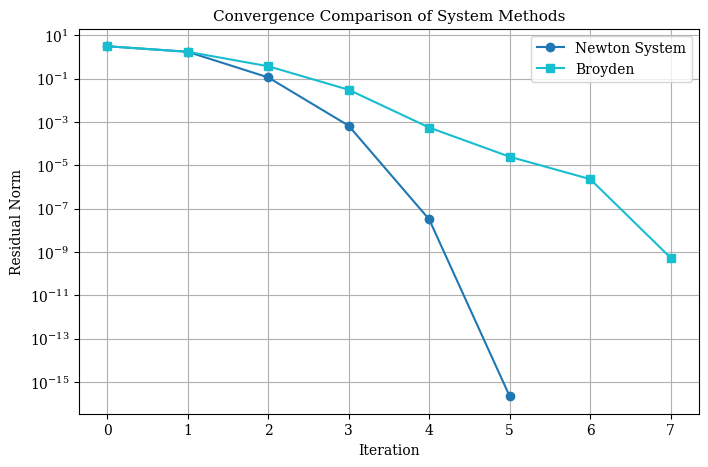

In [13]:
plt.figure(figsize=(8, 5))

# palette without yellow/orange: custom hex list
palette = [
    '#1f77b4', '#17becf', '#2ca02c', '#9467bd',
    '#4daf4a', '#7b4173', '#3182bd', '#66c2a5',
]
method_colors = dict(zip(system_methods.keys(), palette))
markers = ['o', 's', '^', 'D', 'x', 'v', '>', '<']

for (name, result), m in zip(system_methods.items(), markers):
    residuals = residuals_for_plot(result)

    if residuals:
        plt.semilogy(
            range(len(residuals)),
            residuals,
            marker=m,
            color=method_colors[name],
            label=name,
            linewidth=1.5
        )

plt.xlabel("Iteration")
plt.ylabel("Residual Norm")
plt.title("Convergence Comparison of System Methods")

plt.legend()
plt.grid(True)

plt.savefig(
    "../latex/figures/system_methods_convergence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [14]:
residual_consistency_report(system_methods)

,Method,Iterations,History Last Residual,Final Residual,Plot Last Residual,Matches,Converged
0,Newton System,5,3.199400e-08,2.220446e-16,2.220446e-16,True,True
1,Broyden,7,2.287545e-06,5.354870e-10,5.354870e-10,True,True
